# 20. AI Hub 경구약제 이미지 EDA (T1-1)

**데이터 출처**: AI Hub (https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=576)  
> ⚠️ 신청 승인 후 다운로드 가능 (1~5 영업일 소요). 다운로드 전에는 구조 파악 셀만 실행.

**파이프라인 역할**: YOLOv8 + CNN 주요 학습 데이터셋

## EDA 체크리스트
- [ ] 실제 클래스 수 vs. 공표 5,000종
- [ ] 클래스별 이미지 수 분포 (p10, p50, p90, min, max) — 모델링 핵심 수치
- [ ] 어노테이션 포맷 확인 (YOLO/COCO/PascalVOC)
- [ ] 단일 vs. 다중 알약 scene 비율
- [ ] 클래스 레이블 → 품목일련번호 변환 가능 여부
- [ ] 해상도 분포 / 배경 다양성
- [ ] 산출물: `data/interim/aihub_pills_summary.json`

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

ROOT = Path("../../").resolve()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"

# AI Hub 다운로드 후 압축 해제 경로를 여기에 설정
AIHUB_ROOT = RAW / "aihub_pills"
print("AI Hub 데이터 경로:", AIHUB_ROOT)
print("존재 여부:", AIHUB_ROOT.exists())

AI Hub 데이터 경로: /Users/zzuhyeong2/Documents/Tobig's 25th/Conference/Pilliot_tobigs_conference_24_25/data/raw/aihub_pills
존재 여부: True


In [2]:
if not AIHUB_ROOT.exists():
    print("⚠️ 데이터 없음 — AI Hub 신청/다운로드 후 재실행")
    print("신청 URL: https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=576")
else:
    # 디렉토리 구조 확인
    for p in sorted(AIHUB_ROOT.rglob("*"))[:50]:
        print(p.relative_to(AIHUB_ROOT))

1.Training
1.Training/라벨링데이터
1.Training/라벨링데이터/경구약제조합_5000종
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_70_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_75_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_90_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-000250-000573-002483-006192_0_2_0_2_70_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-000250-000573-002483-006192_0_2_0_2_75_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-00

Total images: 2,012
Total classes: 503
Images per class:
count    503.0
mean       4.0
std        0.0
min        4.0
25%        4.0
50%        4.0
75%        4.0
max        4.0


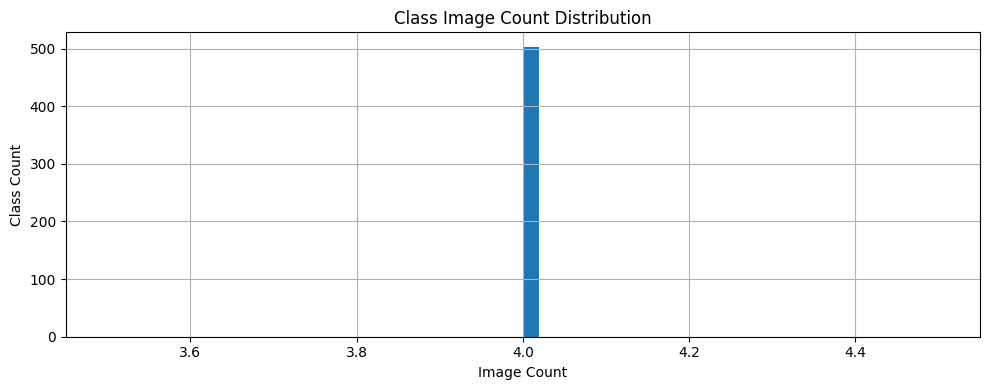

p10: 4 / p50: 4 / p90: 4
Single-image classes: 0


In [3]:
# 이미지 파일 목록 수집
TRAIN_IMAGE = AIHUB_ROOT / "1.Training" / "원천데이터"
if TRAIN_IMAGE.exists():
    img_paths = list(TRAIN_IMAGE.rglob("*.jpg")) + list(TRAIN_IMAGE.rglob("*.png"))
    print(f"Total images: {len(img_paths):,}")

    class_counts = Counter(p.parent.name for p in img_paths)
    print(f"Total classes: {len(class_counts):,}")

    if class_counts:
        counts_series = pd.Series(class_counts)
        print("Images per class:")
        print(counts_series.describe().to_string())

        counts_series.hist(bins=50, figsize=(10, 4))
        plt.title("Class Image Count Distribution")
        plt.xlabel("Image Count")
        plt.ylabel("Class Count")
        plt.tight_layout()
        plt.show()

        print(f"p10: {counts_series.quantile(0.1):.0f} / p50: {counts_series.quantile(0.5):.0f} / p90: {counts_series.quantile(0.9):.0f}")
        print(f"Single-image classes: {(counts_series <= 1).sum():,}")
    else:
        print("No images found — check TRAIN_IMAGE path")

In [4]:
# 어노테이션 파일 구조 확인
if AIHUB_ROOT.exists():
    json_files = list(AIHUB_ROOT.rglob("*.json"))
    txt_files  = list(AIHUB_ROOT.rglob("*.txt"))
    xml_files  = list(AIHUB_ROOT.rglob("*.xml"))
    print(f"json: {len(json_files):,} / txt: {len(txt_files):,} / xml: {len(xml_files):,}")

    # 샘플 어노테이션 파싱
    if json_files:
        with open(json_files[0], encoding="utf-8") as f:
            ann = json.load(f)
        print("JSON 최상위 키:", list(ann.keys()))

json: 2,663,396 / txt: 0 / xml: 0
JSON 최상위 키: ['images', 'type', 'annotations', 'categories']


In [5]:
# 클래스 레이블 → 품목일련번호 변환 가능 여부 확인
if AIHUB_ROOT.exists():
    sample_class_names = list(class_counts.keys())[:10]
    print("샘플 클래스 레이블:")
    for name in sample_class_names:
        print(" ", name)
    print("\n품목일련번호(숫자 9자리) 패턴 여부:")
    import re
    is_seq = [bool(re.match(r'^\d{9}$', name)) for name in sample_class_names]
    print(f"  직접 변환 가능: {sum(is_seq)}/{len(is_seq)}")

샘플 클래스 레이블:
  K-001866-004378-012778-038954
  K-001866-002483-012081-012778
  K-000250-000573-012778-038954
  K-000250-022362-023223-037777
  K-001866-005886-022627-037777
  K-000250-002483-012778-013395
  K-001866-013395-022627-037777
  K-001900-004543-016548-044199
  K-001866-005002-022362-023223
  K-000573-023223-025438-044834

품목일련번호(숫자 9자리) 패턴 여부:
  직접 변환 가능: 0/10


In [6]:
# 해상도 분포 (샘플 500장)
if AIHUB_ROOT.exists():
    try:
        from PIL import Image
        import random
        sample_imgs = random.sample(img_paths, min(500, len(img_paths)))
        sizes = []
        for p in sample_imgs:
            try:
                with Image.open(p) as im:
                    sizes.append(im.size)
            except Exception:
                pass
        df_sizes = pd.DataFrame(sizes, columns=["width", "height"])
        print(df_sizes.describe().to_string())
    except ImportError:
        print("Pillow 미설치 — !pip install Pillow")

       width  height
count  500.0   500.0
mean   976.0  1280.0
std      0.0     0.0
min    976.0  1280.0
25%    976.0  1280.0
50%    976.0  1280.0
75%    976.0  1280.0
max    976.0  1280.0


In [7]:
# 산출물 저장
if AIHUB_ROOT.exists():
    summary = {
        "total_images": len(img_paths),
        "total_classes": len(class_counts),
        "images_per_class_p10": float(counts_series.quantile(0.1)),
        "images_per_class_median": float(counts_series.median()),
        "images_per_class_p90": float(counts_series.quantile(0.9)),
    }
    with open(INTERIM / "aihub_pills_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print(json.dumps(summary, indent=2))
else:
    print("데이터 없음 — 다운로드 후 재실행")

{
  "total_images": 2012,
  "total_classes": 503,
  "images_per_class_p10": 4.0,
  "images_per_class_median": 4.0,
  "images_per_class_p90": 4.0
}
